# Tối ưu hoá log-loss — Santander Product Recommendation

Bài toán: dự đoán khách hàng sẽ **thêm mới** sản phẩm nào trong tháng tới.
Ta giải bằng **hồi quy logistic**, tối thiểu hoá **log-loss**, bằng 4 thuật toán tự cài:

$$\min_w \; F(w)=\underbrace{\frac1n\sum_{i=1}^n\Big[\log\big(1+e^{x_i^\top w}\big)-y_i\,x_i^\top w\Big]+\frac{\lambda_2}{2}\|w\|^2}_{f(w)\ \text{— trơn}}\;+\;\underbrace{\lambda_1\|w\|_1}_{g(w)\ \text{— không trơn}}$$

| Thuật toán | Giải được | Ý tưởng |
|---|---|---|
| **GD** | $f$ trơn | $w \leftarrow w - t\,\nabla f(w)$ |
| **SGD** | $f$ trơn | như GD nhưng gradient tính trên mini-batch |
| **Subgradient** | $F$ có L1 | thay $\nabla f$ bằng một phần tử của $\partial F$ |
| **Proximal** | $F$ có L1 | bước gradient cho $f$, rồi `prox` cho $g$ (ISTA/FISTA) |

Vì sao dùng log-loss: nó là negative log-likelihood của mô hình Bernoulli nên **lồi**
theo $w$ (mọi cực tiểu địa phương đều là toàn cục) và cho ra **xác suất**, dùng để xếp
hạng gợi ý.

**Bố cục:** dữ liệu → đặc trưng → 4 thuật toán → vòng 1 (chung tham số) → vòng 2
(tham số riêng) → nhận xét.

In [1]:
import os, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAU = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # 4 mau cho 4 thuat toan
plt.rcParams["figure.facecolor"] = "white"
np.set_printoptions(precision=4, suppress=True)

## 1. Dữ liệu

### Vì sao KHÔNG dùng `test_ver2.csv` làm validation

`test_ver2.csv` là tập test của cuộc thi Kaggle — **nhãn đã bị giấu**. Nó chỉ có 24 cột
thông tin khách hàng, không có 24 cột sản phẩm `ind_*_ult1` như `train_ver2.csv` (48 cột).
Không có nhãn thì không tính được log-loss, muốn biết điểm phải nộp bài lên Kaggle.

Chạy ô dưới để tự kiểm chứng.

In [2]:
test_cols = pd.read_csv("test_ver2.csv", nrows=1).columns
train_cols = pd.read_csv("train_ver2.csv", nrows=1).columns
print("train_ver2:", len(train_cols), "cot | test_ver2:", len(test_cols), "cot")
print("so cot san pham (nhan) trong train:",
      len([c for c in train_cols if c.startswith("ind_") and c.endswith("ult1")]))
print("so cot san pham (nhan) trong test :",
      len([c for c in test_cols if c.startswith("ind_") and c.endswith("ult1")]))
print("=> test khong co nhan, phai tu tach validation tu train")

train_ver2: 48 cot | test_ver2: 24 cot
so cot san pham (nhan) trong train: 24
so cot san pham (nhan) trong test : 0
=> test khong co nhan, phai tu tach validation tu train


### Cách tự tách train / validation

Đây là dữ liệu **theo thời gian** nên không được chia ngẫu nhiên (sẽ rò rỉ tương lai vào
quá khứ). Ta dùng 2 cặp tháng tách rời nhau:

| | đặc trưng lấy ở tháng | nhãn "thêm mới" ở tháng |
|---|---|---|
| **Train** | 2015-05 | 2015-06 |
| **Validation** | 2016-04 | 2016-05 |

Nhãn: `y = 1` nếu khách **có** sản phẩm ở tháng $t$ nhưng **không có** ở tháng $t-1$.

In [3]:
SAN_PHAM_COLS = [
    "ind_ahor_fin_ult1", "ind_aval_fin_ult1", "ind_cco_fin_ult1", "ind_cder_fin_ult1",
    "ind_cno_fin_ult1", "ind_ctju_fin_ult1", "ind_ctma_fin_ult1", "ind_ctop_fin_ult1",
    "ind_ctpp_fin_ult1", "ind_deco_fin_ult1", "ind_deme_fin_ult1", "ind_dela_fin_ult1",
    "ind_ecue_fin_ult1", "ind_fond_fin_ult1", "ind_hip_fin_ult1", "ind_plan_fin_ult1",
    "ind_pres_fin_ult1", "ind_reca_fin_ult1", "ind_tjcr_fin_ult1", "ind_valo_fin_ult1",
    "ind_viv_fin_ult1", "ind_nomina_ult1", "ind_nom_pens_ult1", "ind_recibo_ult1"]

THANG = ["2015-05-28", "2015-06-28", "2016-04-28", "2016-05-28"]
COT_DOC = (["fecha_dato", "ncodpers", "age", "antiguedad", "renta", "ind_nuevo",
            "ind_actividad_cliente", "sexo", "segmento", "tiprel_1mes",
            "canal_entrada", "fecha_alta"] + SAN_PHAM_COLS)

# File train_ver2.csv nang 2.3GB nen doc theo tung chunk, chi giu 4 thang can dung.
# Lan dau mat ~40 giay, sau do luu cache lai.
if not os.path.exists("cache"):
    os.makedirs("cache")

if os.path.exists("cache/4thang.pkl"):
    df = pd.read_pickle("cache/4thang.pkl")
    print("doc tu cache")
else:
    t0 = time.time()
    giu = []
    for chunk in pd.read_csv("train_ver2.csv", usecols=COT_DOC, dtype=str,
                             chunksize=1000000):
        giu.append(chunk[chunk["fecha_dato"].isin(THANG)])
    df = pd.concat(giu, ignore_index=True)
    df.to_pickle("cache/4thang.pkl")
    print("quet xong sau %.0f giay" % (time.time() - t0))

print(df.shape)
df.head(3)

quet xong sau 30 giay
(3123794, 36)


,fecha_dato,ncodpers,sexo,age,fecha_alta,ind_nuevo,antiguedad,tiprel_1mes,canal_entrada,ind_actividad_cliente,...,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-05-28,1061260,H,24,2012-09-17,0,34,I,KHE,0,...,0,0,0,0,0,0,0,0,0,0
1,2015-05-28,1061283,H,22,2012-09-17,0,34,I,KHE,0,...,0,0,0,0,0,0,0,0,0,0
2,2015-05-28,1061284,H,24,2012-09-17,0,34,I,KHE,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# ---- lam sach ----
for c in SAN_PHAM_COLS:                      # cot san pham: 0/1, co vai o trong
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.int8)

df["age"] = pd.to_numeric(df["age"], errors="coerce").clip(18, 95)

df["antiguedad"] = pd.to_numeric(df["antiguedad"], errors="coerce")
df.loc[df["antiguedad"] < 0, "antiguedad"] = np.nan     # co -999999 nghia la thieu
df["antiguedad"] = df["antiguedad"].clip(0, 260)

df["renta"] = pd.to_numeric(df["renta"], errors="coerce")
df["renta"] = np.log1p(df["renta"].clip(0, 1500000))    # thu nhap lech phai rat manh

df["alta_year"] = pd.to_datetime(df["fecha_alta"], errors="coerce").dt.year
df["ind_nuevo"] = pd.to_numeric(df["ind_nuevo"], errors="coerce").fillna(0)
df["ind_actividad_cliente"] = pd.to_numeric(df["ind_actividad_cliente"],
                                            errors="coerce").fillna(0)

COT_SO = ["age", "antiguedad", "renta", "ind_nuevo", "ind_actividad_cliente", "alta_year"]
for c in COT_SO:
    df[c] = df[c].astype(float).fillna(df[c].median())

for c in ["sexo", "segmento", "tiprel_1mes", "canal_entrada"]:
    df[c] = df[c].fillna("NA").astype(str).str.strip().replace("", "NA")

df["ncodpers"] = df["ncodpers"].astype(np.int64)
print("da lam sach")

da lam sach


## 2. Bộ đặc trưng — vì sao chỉ cần ~39 cột

Bản đầu tiên tôi làm ra **93 cột**, phần lớn là do one-hot: `cod_prov` 20 tỉnh,
`canal_entrada` 10 kênh, `pais_residencia`… cộng lại thành 61 cột. Đo thử thì 61 cột đó
gần như không đáng:

| bộ đặc trưng | số cột | log-loss va | AUC |
|---|---|---|---|
| chỉ intercept | 1 | 0,060842 | 0,486 |
| + 6 cột số | 8 | 0,052127 | 0,791 |
| + 24 cờ sở hữu tháng trước | 32 | 0,045227 | 0,901 |
| + vài dummy hạng mục | **~39** | **0,04437** | **0,916** |
| + toàn bộ 61 one-hot | 93 | 0,044244 | 0,917 |

Thêm 54 cột nữa chỉ đổi được 0,0001 log-loss và 0,001 AUC → **bỏ**. Bộ dùng ở đây:

- **1** intercept (không bị phạt)
- **6** cột số: age, antiguedad, log(renta), ind_nuevo, ind_actividad_cliente, alta_year
- **~8** dummy từ 4 biến hạng mục: sexo, segmento, tiprel_1mes, canal_entrada (top-3)
- **24** cờ sở hữu ở tháng $t-1$ — **tín hiệu mạnh nhất** (một mình nhóm này kéo AUC
  từ 0,79 lên 0,90): người đã có sản phẩm nào thì rất dự đoán được họ mua thêm gì.

Mọi cột chuẩn hoá z-score theo thống kê **tập train** (điều kiện số tốt hơn → GD/SGD hội
tụ nhanh hơn nhiều).

In [5]:
def tao_du_lieu(df, thang_lag, thang_dich, muc_cat=None, tb=None, do_lech=None):
    '''Ghep thang t voi t-1 -> nhan 'them moi' + ma tran dac trung.'''
    hien_tai = df[df["fecha_dato"] == thang_dich]
    truoc = df[df["fecha_dato"] == thang_lag][["ncodpers"] + SAN_PHAM_COLS]
    truoc = truoc.rename(columns={c: c + "_lag" for c in SAN_PHAM_COLS})
    m = hien_tai.merge(truoc, on="ncodpers")        # chi giu khach co ca 2 thang

    # nhan: co o thang t nhung KHONG co o thang t-1
    Y = ((m[SAN_PHAM_COLS].values == 1) &
         (m[[c + "_lag" for c in SAN_PHAM_COLS]].values == 0)).astype(np.int8)

    # muc cua bien hang muc phai chot tren TAP TRAIN, khong duoc nhin validation
    if muc_cat is None:
        muc_cat = {"sexo": ["V"], "segmento": ["02 - PARTICULARES", "03 - UNIVERSITARIO"],
                   "tiprel_1mes": ["I"],
                   "canal_entrada": list(m["canal_entrada"].value_counts().index[:3])}

    khoi = [m[COT_SO].values.astype(float)]
    ten = list(COT_SO)
    for c, cac_muc in muc_cat.items():
        for mm in cac_muc:
            khoi.append((m[c] == mm).values.astype(float).reshape(-1, 1))
            ten.append("%s=%s" % (c, mm))
    khoi.append(m[[c + "_lag" for c in SAN_PHAM_COLS]].values.astype(float))
    ten += [c + "_lag" for c in SAN_PHAM_COLS]
    X = np.hstack(khoi)

    if tb is None:                                   # chuan hoa theo tap train
        tb, do_lech = X.mean(axis=0), X.std(axis=0)
        do_lech[do_lech < 1e-8] = 1.0
    X = (X - tb) / do_lech

    X = np.hstack([np.ones((len(X), 1)), X])         # them cot intercept
    return X, Y, ["intercept"] + ten, muc_cat, tb, do_lech


X_tr, Y_tr, ten_cot, muc_cat, tb, do_lech = tao_du_lieu(df, "2015-05-28", "2015-06-28")
X_va, Y_va, _, _, _, _ = tao_du_lieu(df, "2016-04-28", "2016-05-28", muc_cat, tb, do_lech)

print("X_tr:", X_tr.shape, " X_va:", X_va.shape)
print("\n%d cot:" % len(ten_cot))
print("  1 intercept + %d so + %d dummy + 24 lag" %
      (len(COT_SO), len(ten_cot) - 1 - len(COT_SO) - 24))
print("  dummy:", [t for t in ten_cot if "=" in t])

X_tr: (628603, 38)  X_va: (926663, 38)

38 cot:
  1 intercept + 6 so + 7 dummy + 24 lag
  dummy: ['sexo=V', 'segmento=02 - PARTICULARES', 'segmento=03 - UNIVERSITARIO', 'tiprel_1mes=I', 'canal_entrada=KHE', 'canal_entrada=KAT', 'canal_entrada=KFC']


In [6]:
# chon 1 san pham de lam vi du: san pham co ti le them moi cao nhat
ti_le = Y_tr.mean(axis=0)
for j in np.argsort(-ti_le)[:5]:
    print("  %-22s %6.3f%%" % (SAN_PHAM_COLS[j], ti_le[j] * 100))

SAN_PHAM = "ind_recibo_ult1"
k = SAN_PHAM_COLS.index(SAN_PHAM)
y_tr = Y_tr[:, k].astype(float)
y_va = Y_va[:, k].astype(float)
n, d = X_tr.shape
print("\nBai toan: du doan khach THEM MOI '%s'" % SAN_PHAM)
print("ti le duong: train %.3f%% | valid %.3f%%" % (y_tr.mean()*100, y_va.mean()*100))
print("=> rat mat can bang, nen log-loss cua mo hinh 'doan bua' da rat nho")

  ind_recibo_ult1         1.435%
  ind_nom_pens_ult1       1.294%
  ind_cco_fin_ult1        1.048%
  ind_nomina_ult1         0.807%
  ind_tjcr_fin_ult1       0.741%

Bai toan: du doan khach THEM MOI 'ind_recibo_ult1'
ti le duong: train 1.435% | valid 1.097%
=> rat mat can bang, nen log-loss cua mo hinh 'doan bua' da rat nho


## 3. Log-loss, gradient và hằng số Lipschitz

$$f(w)=\frac1n\sum_i\big[\log(1+e^{z_i})-y_i z_i\big]+\frac{\lambda_2}{2}\|w\|^2,
\qquad z=Xw$$
$$\nabla f(w)=\frac1n X^\top\big(\sigma(Xw)-y\big)+\lambda_2 w$$

Hai mẹo về số học:
- `np.logaddexp(0, z)` thay cho `log(1+exp(z))` để không bị tràn khi $z$ lớn.
- sigmoid tách 2 trường hợp $z\ge0$ và $z<0$, cũng để khỏi tràn.

Vì $\sigma'(z)\le\frac14$ nên $\nabla f$ Lipschitz với
$L=\frac{\sigma_{\max}(X)^2}{4n}+\lambda_2$, và bước $t=1/L$ **luôn** đảm bảo GD hội tụ.

In [7]:
def sigmoid(z):
    out = np.zeros_like(z, dtype=float)
    duong = z >= 0                          # tach 2 truong hop cho khoi tran so
    out[duong] = 1 / (1 + np.exp(-z[duong]))
    e = np.exp(z[~duong])
    out[~duong] = e / (1 + e)
    return out


def logloss(w, X, y, lam2=0.0):
    '''Phan TRON: log-loss trung binh + phat L2 (khong phat intercept).'''
    z = X @ w
    loss = np.mean(np.logaddexp(0, z) - y * z)     # = -[y log p + (1-y) log(1-p)]
    if lam2 > 0:
        loss = loss + 0.5 * lam2 * np.sum(w[1:] ** 2)
    return loss


def grad(w, X, y, lam2=0.0):
    g = X.T @ (sigmoid(X @ w) - y) / X.shape[0]
    if lam2 > 0:
        g = g.copy()
        g[1:] = g[1:] + lam2 * w[1:]
    return g


def F_muc_tieu(w, X, y, lam1=0.0, lam2=0.0):
    '''Ham muc tieu day du F = phan tron + lam1*||w||_1'''
    F = logloss(w, X, y, lam2)
    if lam1 > 0:
        F = F + lam1 * np.sum(np.abs(w[1:]))
    return F


def hang_so_lipschitz(X, lam2=0.0):
    '''L = sigma_max(X)^2/(4n) + lam2, tim sigma_max bang power iteration.'''
    v = np.random.RandomState(0).rand(X.shape[1])
    v = v / np.linalg.norm(v)
    for _ in range(50):
        v = X.T @ (X @ v)
        v = v / np.linalg.norm(v)
    return np.sum((X @ v) ** 2) / (4 * X.shape[0]) + lam2

In [8]:
# Kiem tra gradient bang sai phan huu han - PHAI LAM truoc khi chay thuat toan
def kiem_tra_grad(w, X, y, lam2=0.0, eps=1e-6):
    g = grad(w, X, y, lam2)
    sai_so = 0.0
    for j in np.random.RandomState(0).choice(len(w), 10, replace=False):
        w1, w2 = w.copy(), w.copy()
        w1[j] += eps
        w2[j] -= eps
        so_sai_phan = (logloss(w1, X, y, lam2) - logloss(w2, X, y, lam2)) / (2 * eps)
        sai_so = max(sai_so, abs(so_sai_phan - g[j]))
    return sai_so

lam1, lam2 = 1e-3, 1e-6
VONG, BATCH = 40, 1024          # ngan sach chung: 40 lan duyet du lieu

w_thu = np.random.RandomState(0).randn(d) * 0.05
print("sai so gradient:", kiem_tra_grad(w_thu, X_tr, y_tr, lam2), "  (phai ~1e-9)")

L = hang_so_lipschitz(X_tr, lam2)
eta = 1 / L
print("L = %.4f -> buoc an toan 1/L = %.4f" % (L, eta))

p0 = y_tr.mean()
moc = -(p0 * np.log(p0) + (1 - p0) * np.log(1 - p0))
print("log-loss cua mo hinh hang so = %.6f   <-- moc can vuot" % moc)

sai so gradient: 1.4038720880238387e-10   (phai ~1e-9)


L = 1.6091 -> buoc an toan 1/L = 0.6215
log-loss cua mo hinh hang so = 0.075165   <-- moc can vuot


## 4. Hàm dưới đạo hàm (subgradient)

Khi thêm $\lambda_1\|w\|_1$, hàm mục tiêu **không khả vi tại $w_j=0$** — mà đó lại đúng là
chỗ nghiệm hay nằm. Thay gradient bằng **dưới vi phân**:

$$\partial F(w)=\nabla f(w)+\lambda_1\,\partial\|w\|_1,\qquad
\partial|w_j|=\begin{cases}\{\mathrm{sign}(w_j)\}, & w_j\neq0\\[2pt] [-1,1], & w_j=0\end{cases}$$

Tại $w_j=0$ dưới vi phân là **cả một đoạn**, nên phải *chọn* một phần tử. Ta chọn phần tử
có **chuẩn nhỏ nhất**:

$$g_j=\nabla_j f(w)-\mathrm{clip}\big(\nabla_j f(w),\,-\lambda_1,\,\lambda_1\big)$$

Lý do chọn kiểu này: $\|g\|=0$ **khi và chỉ khi** $0\in\partial F(w)$, tức $w$ tối ưu →
dùng luôn làm điều kiện dừng / kiểm tra KKT.

In [9]:
def duoi_dao_ham(w, X, y, lam1=0.0, lam2=0.0, idx=None, cach_chon="min_norm"):
    '''Tra ve MOT phan tu g thuoc duoi vi phan dF(w).'''
    if idx is not None:                     # idx = mini-batch -> ban ngau nhien
        g = grad(w, X[idx], y[idx], lam2)
    else:
        g = grad(w, X, y, lam2)
    if lam1 == 0:
        return g

    g = g.copy()
    khac_0 = w != 0
    bang_0 = w == 0
    khac_0[0] = bang_0[0] = False           # bo intercept (khong bi phat)

    g[khac_0] += lam1 * np.sign(w[khac_0])            # w_j != 0: dao ham duy nhat
    if cach_chon == "min_norm":                       # w_j == 0: phai CHON
        g[bang_0] -= np.clip(g[bang_0], -lam1, lam1)  # phan tu chuan nho nhat
    elif cach_chon == "random":
        g[bang_0] += np.random.uniform(-lam1, lam1, bang_0.sum())
    return g


print("||g|| tai w=0 :", np.linalg.norm(duoi_dao_ham(np.zeros(d), X_tr, y_tr, lam1, lam2)))
print("(khac 0 => w=0 chua phai nghiem toi uu)")

||g|| tai w=0 : 0.48612602480099776
(khac 0 => w=0 chua phai nghiem toi uu)


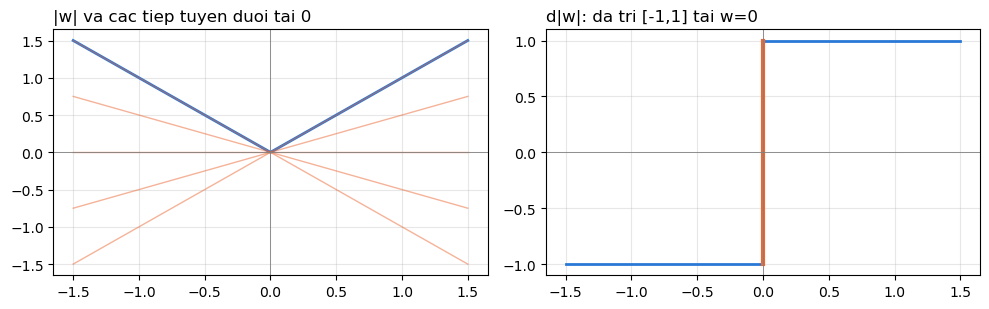

In [10]:
# Minh hoa: duoi vi phan cua |w| tai 0 la ca doan [-1, 1]
t = np.linspace(-1.5, 1.5, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

ax[0].plot(t, np.abs(t), color=MAU[0], lw=2)
for s in [-1, -0.5, 0, 0.5, 1]:                       # cac tiep tuyen duoi tai 0
    ax[0].plot(t, s * t, color=MAU[1], lw=1, alpha=0.5)
ax[0].set_title("|w| va cac tiep tuyen duoi tai 0", loc="left")

ax[1].plot(t[t < 0], -np.ones((t < 0).sum()), color=MAU[0], lw=2)
ax[1].plot(t[t > 0], np.ones((t > 0).sum()), color=MAU[0], lw=2)
ax[1].plot([0, 0], [-1, 1], color=MAU[1], lw=3)       # ca doan [-1,1] tai w=0
ax[1].set_title("d|w|: da tri [-1,1] tai w=0", loc="left")

for a in ax:
    a.axhline(0, color="gray", lw=0.6)
    a.axvline(0, color="gray", lw=0.6)
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Toán tử proximal

$$\mathrm{prox}_{tg}(v)=\arg\min_u\Big\{g(u)+\frac{1}{2t}\|u-v\|^2\Big\}$$

Với $g(w)=\lambda_1\|w\|_1$, bài toán **tách theo từng toạ độ** nên có nghiệm dạng đóng —
**soft-thresholding**:

$$\big[\mathrm{prox}_{t\lambda_1\|\cdot\|_1}(v)\big]_j=\mathrm{sign}(v_j)\max\big(|v_j|-t\lambda_1,\ 0\big)$$

Đây là điểm mấu chốt: toán tử này **đặt hẳn** các toạ độ nhỏ **về đúng 0** → nghiệm thưa
thật sự, khác hẳn subgradient (chỉ làm hệ số nhỏ dần chứ hiếm khi bằng 0).

In [11]:
def prox_L1(v, t, lam1):
    '''Soft-thresholding. Intercept (v[0]) khong bi phat nen giu nguyen.'''
    u = v.copy()
    u[1:] = np.sign(v[1:]) * np.maximum(np.abs(v[1:]) - t * lam1, 0)
    return u


def prox_elastic_net(v, t, lam1, lam2):
    '''prox cua lam1*||w||_1 + lam2/2*||w||^2 = soft-threshold roi co lai.'''
    u = prox_L1(v, t, lam1)
    u[1:] = u[1:] / (1 + t * lam2)
    return u


# Kiem chung: giai truc tiep bai toan 1 chieu tren luoi xem co khop cong thuc khong
v, t_thu, l1 = np.array([0.0, 0.7, -0.30, 0.05, 2.0]), 0.5, 0.4
luoi = np.linspace(-4, 4, 400001)
giai_tay = [v[0]] + [luoi[np.argmin(l1*np.abs(luoi) + (luoi - v[j])**2/(2*t_thu))]
                     for j in range(1, 5)]
print("cong thuc dang dong:", prox_L1(v, t_thu, l1))
print("giai truc tiep     :", np.array(giai_tay))
print("sai lech toi da    :", np.abs(prox_L1(v, t_thu, l1) - np.array(giai_tay)).max())

cong thuc dang dong: [ 0.   0.5 -0.1  0.   1.8]
giai truc tiep     : [ 0.   0.5 -0.1  0.   1.8]
sai lech toi da    : 6.661338147750939e-16


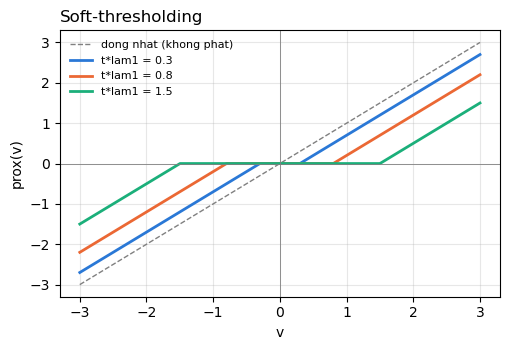

In [12]:
# Hinh dang soft-thresholding: vung phang chinh la cho he so bi ep ve 0
v = np.linspace(-3, 3, 600)
plt.figure(figsize=(5.2, 3.6))
plt.plot(v, v, color="gray", lw=1, ls="--", label="dong nhat (khong phat)")
for i, nguong in enumerate([0.3, 0.8, 1.5]):
    plt.plot(v, np.sign(v) * np.maximum(np.abs(v) - nguong, 0), color=MAU[i], lw=2,
             label="t*lam1 = %.1f" % nguong)
plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)
plt.xlabel("v"); plt.ylabel("prox(v)"); plt.grid(alpha=0.3)
plt.title("Soft-thresholding", loc="left"); plt.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 6. Bốn thuật toán

Mỗi hàm trả về `(w, lich_su)`, trong đó `lich_su` ghi lại $F$, thời gian, số hệ số khác 0
và log-loss validation sau mỗi lần duyệt dữ liệu — để vẽ đồ thị hội tụ.

In [13]:
def ghi(ls, w, X, y, lam1, lam2, val, t0, vong):
    '''Ghi lai tinh trang sau moi lan duyet du lieu.'''
    ls["vong"].append(vong)
    ls["F"].append(F_muc_tieu(w, X, y, lam1, lam2))
    ls["time"].append(time.time() - t0)
    ls["nnz"].append(int(np.sum(w != 0)))            # so he so khac 0
    ls["val"].append(logloss(w, val[0], val[1]))

def lich_su_moi():
    return {"vong": [], "F": [], "time": [], "nnz": [], "val": []}

def buoc_hoc(kieu, eta0, k):
    if kieu == "hang_so":    return eta0
    if kieu == "1/k":        return eta0 / (1 + 1e-3 * k)
    if kieu == "1/sqrt(k)":  return eta0 / np.sqrt(1 + k)
    raise ValueError(kieu)

In [14]:
def GD(X, y, val, lam2=0.0, buoc=None, so_vong=40, line_search=False):
    '''
    Gradient descent:  w = w - t * grad(w)
    buoc=None       -> t = 1/L (an toan, dam bao giam don dieu)
    line_search     -> Armijo: thu buoc gap doi lan truoc roi co dan lai
                       den khi f(w - t*g) <= f(w) - c*t*||g||^2
    Chi dung duoc khi lam1 = 0 vi ||w||_1 khong kha vi.
    '''
    w = np.zeros(X.shape[1])
    t = 1 / hang_so_lipschitz(X, lam2) if buoc is None else buoc

    ls = lich_su_moi(); t0 = time.time()
    ghi(ls, w, X, y, 0, lam2, val, t0, 0)

    for k in range(1, so_vong + 1):
        g = grad(w, X, y, lam2)
        if line_search:
            f0 = logloss(w, X, y, lam2)
            chuan = np.sum(g ** 2)
            t = t * 2                        # thu buoc lon hon lan truoc
            for _ in range(50):
                w_moi = w - t * g
                if logloss(w_moi, X, y, lam2) <= f0 - 1e-4 * t * chuan:
                    break
                t = t / 2                    # chua dat thi co lai
            w = w_moi
        else:
            w = w - t * g
        ghi(ls, w, X, y, 0, lam2, val, t0, k)
    return w, ls

In [15]:
def SGD(X, y, val, lam2=0.0, batch=1024, so_vong=40, eta0=0.1, kieu_buoc="1/k",
        momentum=0.0, trung_binh=False, seed=0):
    '''
    SGD mini-batch:  w = w - eta_k * grad_B(w)
    grad_B la uoc luong khong chech cua grad, moi buoc re hon n/batch lan nhung
    co nhieu -> can buoc giam dan (dieu kien Robbins-Monro).
    '''
    n = X.shape[0]
    rs = np.random.RandomState(seed)
    w = np.zeros(X.shape[1])
    v = np.zeros(X.shape[1])
    w_tb, dem = w.copy(), 1

    ls = lich_su_moi(); t0 = time.time()
    ghi(ls, w, X, y, 0, lam2, val, t0, 0)

    k = 0
    for epoch in range(1, so_vong + 1):
        thu_tu = rs.permutation(n)                   # xao tron moi epoch
        for i in range(0, n, batch):
            idx = thu_tu[i:i + batch]
            Xb, yb = X[idx], y[idx]
            g = Xb.T @ (sigmoid(Xb @ w) - yb) / len(idx)
            if lam2 > 0:
                g[1:] = g[1:] + lam2 * w[1:]

            eta = buoc_hoc(kieu_buoc, eta0, k)
            if momentum > 0:
                v = momentum * v + g
                w = w - eta * v
            else:
                w = w - eta * g
            k += 1
            if trung_binh:                           # trung binh Polyak
                dem += 1
                w_tb = w_tb + (w - w_tb) / dem
        ghi(ls, w_tb if trung_binh else w, X, y, 0, lam2, val, t0, epoch)
    return (w_tb if trung_binh else w), ls

In [16]:
def SUBGRADIENT(X, y, val, lam1=1e-3, lam2=0.0, eta0=None, so_vong=40,
                kieu_buoc="1/sqrt(k)", cach_chon="min_norm"):
    '''
    Phuong phap duoi dao ham:  w = w - eta_k * g_k,  g_k thuoc dF(w_k)

    Khac GD o 2 diem quan trong:
      - F(w_k) KHONG giam don dieu -> phai nho lai nghiem tot nhat da gap
      - buoc phai giam dan, toc do chi O(1/sqrt(k))  (ISTA la O(1/k))
    '''
    w = np.zeros(X.shape[1])
    if eta0 is None:
        eta0 = 1 / hang_so_lipschitz(X, lam2)

    ls = lich_su_moi(); t0 = time.time()
    ghi(ls, w, X, y, lam1, lam2, val, t0, 0)

    w_tot = w.copy()
    F_tot = F_muc_tieu(w, X, y, lam1, lam2)

    for k in range(1, so_vong + 1):
        g = duoi_dao_ham(w, X, y, lam1, lam2, cach_chon=cach_chon)
        w = w - buoc_hoc(kieu_buoc, eta0, k) * g

        F = F_muc_tieu(w, X, y, lam1, lam2)
        if F < F_tot:                                # nho lai nghiem tot nhat
            F_tot, w_tot = F, w.copy()
        ghi(ls, w, X, y, lam1, lam2, val, t0, k)
    return w_tot, ls

In [17]:
def PROXIMAL(X, y, val, lam1=1e-3, lam2=0.0, buoc=None, so_vong=40,
             gia_toc=False, line_search=False, kieu_prox="l1"):
    '''
    ISTA:  w = prox( w - t*grad(w) )
           di mot buoc gradient tren phan TRON roi "chieu mem" bang prox cua
           phan KHONG TRON -> nghiem thua that su.

    gia_toc=True -> FISTA, them quan tinh Nesterov:
           v = w + (k-1)/(k+2)*(w - w_truoc);  w = prox( v - t*grad(v) )
           Toc do: ISTA O(1/k) -> FISTA O(1/k^2), chi phi moi vong nhu nhau.
    '''
    w = np.zeros(X.shape[1])
    t = 1 / hang_so_lipschitz(X, lam2) if buoc is None else buoc
    lam2_tron = 0.0 if kieu_prox == "elastic_net" else lam2   # tranh phat 2 lan

    def lam_prox(u, t):
        if kieu_prox == "l1":           return prox_L1(u, t, lam1)
        if kieu_prox == "elastic_net":  return prox_elastic_net(u, t, lam1, lam2)
        if kieu_prox == "khong":        return u        # prox = dong nhat -> ISTA == GD
        raise ValueError(kieu_prox)

    ls = lich_su_moi(); t0 = time.time()
    ghi(ls, w, X, y, lam1, lam2, val, t0, 0)

    w_truoc = w.copy()
    for k in range(1, so_vong + 1):
        v = w + (k - 1) / (k + 2) * (w - w_truoc) if gia_toc else w
        g = grad(v, X, y, lam2_tron)

        if line_search:
            fv = logloss(v, X, y, lam2_tron)
            t = t * 1.5                              # thu buoc lon hon truoc
            for _ in range(50):
                w_moi = lam_prox(v - t * g, t)
                hieu = w_moi - v
                if logloss(w_moi, X, y, lam2_tron) <= fv + g @ hieu + hieu @ hieu / (2*t):
                    break
                t = t / 2
        else:
            w_moi = lam_prox(v - t * g, t)

        w_truoc, w = w, w_moi
        ghi(ls, w, X, y, lam1, lam2, val, t0, k)
    return w, ls

In [18]:
# Kiem tra nhat quan: lam1 = 0 thi prox la anh xa dong nhat -> ISTA phai TRUNG GD
a, _ = PROXIMAL(X_tr, y_tr, (X_va, y_va), 0.0, lam2, buoc=eta, so_vong=20,
                kieu_prox="khong")
b, _ = GD(X_tr, y_tr, (X_va, y_va), lam2, buoc=eta, so_vong=20)
print("ISTA(prox=khong) == GD ?", np.allclose(a, b), "| lech toi da:", np.abs(a-b).max())

ISTA(prox=khong) == GD ? True | lech toi da: 0.0


## 7. Vòng 1 — cả 4 thuật toán dùng CHUNG một bộ tham số

$w_0=0$ · bước $1/L$ · 40 lần duyệt dữ liệu · $B=1024$ · $\lambda_1,\lambda_2$ như nhau ·
không bật cải tiến nào.

> **Đọc bảng cho đúng:** GD/SGD chỉ tối ưu $f$ (không xử lý được L1), còn
> Subgradient/Proximal tối ưu $F=f+\lambda_1\|w\|_1$ → cột `F` là hai hàm khác nhau.
> Cột **log-loss** là log-loss trần (không cộng phạt) nên mới so chéo được.

In [19]:
def auc(y, p):
    '''AUC = xac suat mau duong duoc xep hang cao hon mau am.'''
    hang = np.empty(len(p))
    hang[np.argsort(p)] = np.arange(1, len(p) + 1)
    n_duong, n_am = y.sum(), len(y) - y.sum()
    return (hang[y == 1].sum() - n_duong * (n_duong + 1) / 2) / (n_duong * n_am)

def danh_gia(w, ls, lam1):
    if not np.all(np.isfinite(w)):                   # cau hinh phan ky
        return {"F": np.inf, "val": np.inf, "auc": np.nan,
                "nnz": int(np.sum(w != 0)), "giay": ls["time"][-1]}
    return {"F": F_muc_tieu(w, X_tr, y_tr, lam1, lam2),
            "val": logloss(w, X_va, y_va),
            "auc": auc(y_va, sigmoid(X_va @ w)),
            "nnz": int(np.sum(w != 0)),
            "giay": ls["time"][-1]}

def in_bang(dong, tieu_de):
    print("\n" + tieu_de)
    print("%-13s%-30s%12s%13s%8s%6s%8s" %
          ("thuat toan", "cau hinh", "F (train)", "log-loss va", "AUC", "nnz", "giay"))
    print("-" * 92)
    for ten, cfg, e in dong:
        print("%-13s%-30s%12.8f%13.6f%8.4f%6d%8.1f" %
              (ten, cfg, e["F"], e["val"], e["auc"], e["nnz"], e["giay"]))

TEN_4 = ["GD", "SGD", "Subgradient", "Proximal"]
val = (X_va, y_va)

In [20]:
kq1 = [
    ("buoc 1/L",        GD(X_tr, y_tr, val, lam2, buoc=eta, so_vong=VONG)),
    ("buoc 1/L, B=1024", SGD(X_tr, y_tr, val, lam2, batch=BATCH, so_vong=VONG,
                             eta0=eta, kieu_buoc="hang_so")),
    ("buoc 1/L",        SUBGRADIENT(X_tr, y_tr, val, lam1, lam2, eta0=eta,
                                    so_vong=VONG, kieu_buoc="hang_so")),
    ("ISTA, buoc 1/L",  PROXIMAL(X_tr, y_tr, val, lam1, lam2, buoc=eta, so_vong=VONG)),
]

lam1_tung_tt = [0.0, 0.0, lam1, lam1]        # GD/SGD khong co L1
ev1 = [danh_gia(w, ls, l1) for (_, (w, ls)), l1 in zip(kq1, lam1_tung_tt)]
in_bang([(TEN_4[i], kq1[i][0], ev1[i]) for i in range(4)], "KET QUA VONG 1")


KET QUA VONG 1
thuat toan   cau hinh                         F (train)  log-loss va     AUC   nnz    giay
--------------------------------------------------------------------------------------------
GD           buoc 1/L                        0.08833962     0.077420  0.8935    38     2.8
SGD          buoc 1/L, B=1024                0.05738911     0.044459  0.9152    38    13.5
Subgradient  buoc 1/L                        0.08953733     0.078062  0.8928    30     3.5
Proximal     ISTA, buoc 1/L                  0.08953695     0.078055  0.8925    25     2.8


In [21]:
# F* tham chieu: chay FISTA that lau de biet gia tri toi uu, dung ve do thi hoi tu
bo_nho = {}
def F_sao(l1):
    if l1 not in bo_nho:
        w, _ = PROXIMAL(X_tr, y_tr, val, l1, lam2, so_vong=800, gia_toc=True,
                        kieu_prox="l1" if l1 > 0 else "khong")
        bo_nho[l1] = (F_muc_tieu(w, X_tr, y_tr, l1, lam2), w)
    return bo_nho[l1][0]

print("F* (lam1=%g) = %.10f" % (lam1, F_sao(lam1)))
print("F* (chi phan tron)  = %.10f" % F_sao(0.0))

F* (lam1=0.001) = 0.0631721226


F* (chi phan tron)  = 0.0573246615


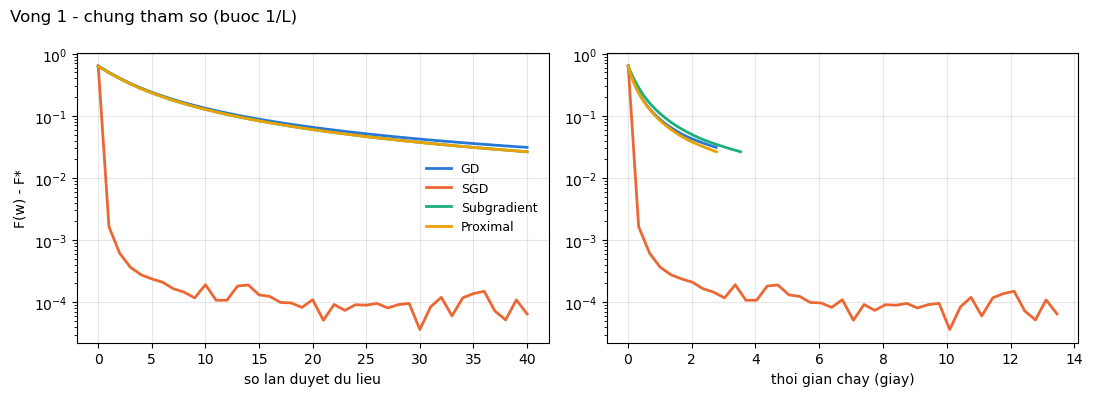

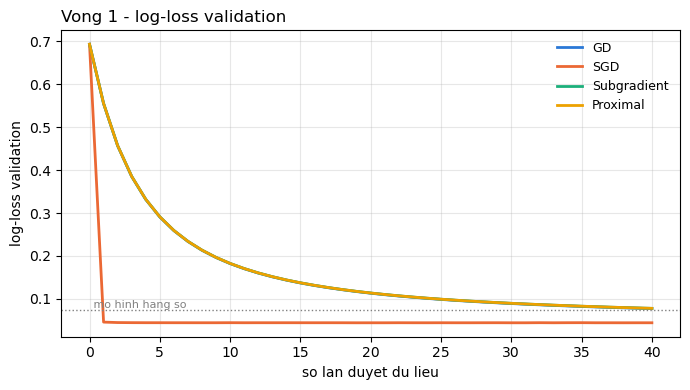

In [22]:
def ve_hoi_tu(ket_qua, F_sao_list, tieu_de):
    '''2 khung: hoi tu theo so lan duyet du lieu va theo thoi gian thuc.'''
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, cot, nhan in zip(axes, ["vong", "time"],
                             ["so lan duyet du lieu", "thoi gian chay (giay)"]):
        for i, (ten, ls) in enumerate(ket_qua):
            # moi thuat toan so voi F* cua dung bai toan NO giai
            gap = np.maximum(np.array(ls["F"]) - F_sao_list[i], 1e-16)
            ax.plot(ls[cot], gap, color=MAU[i], lw=2, label=ten)
        ax.set_yscale("log"); ax.grid(alpha=0.3)
        ax.set_xlabel(nhan)
    axes[0].set_ylabel("F(w) - F*"); axes[0].legend(frameon=False, fontsize=9)
    fig.suptitle(tieu_de, x=0.01, ha="left")
    plt.tight_layout(); plt.show()

def ve_val(ket_qua, tieu_de):
    '''Log-loss validation - chi so SO SANH DUOC giua ca 4 thuat toan.'''
    plt.figure(figsize=(7, 4))
    for i, (ten, ls) in enumerate(ket_qua):
        plt.plot(ls["vong"], ls["val"], color=MAU[i], lw=2, label=ten)
    plt.axhline(moc, color="gray", ls=":", lw=1)
    plt.text(0, moc, " mo hinh hang so", color="gray", fontsize=8, va="bottom")
    plt.xlabel("so lan duyet du lieu"); plt.ylabel("log-loss validation")
    plt.title(tieu_de, loc="left"); plt.grid(alpha=0.3)
    plt.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

ve1 = [(TEN_4[i], kq1[i][1][1]) for i in range(4)]
ve_hoi_tu(ve1, [F_sao(0.0), F_sao(0.0), F_sao(lam1), F_sao(lam1)],
          "Vong 1 - chung tham so (buoc 1/L)")
ve_val(ve1, "Vong 1 - log-loss validation")

### Nhận xét vòng 1

Bước $1/L$ là bước **của GD** — đem áp cho 3 thuật toán còn lại là thiên vị:

- **SGD**: $1/L$ quá nhỏ một cách vô lý, vì mỗi epoch SGD đi $n/B\approx 614$ bước chứ
  không phải 1 → nó vẫn về đích sớm nhất dù dùng đúng bước đó.
- **Subgradient**: sai *kiểu*. Lý thuyết đòi bước **giảm dần**
  ($\sum\eta_k=\infty,\ \sum\eta_k^2<\infty$); bước hằng chỉ đưa nghiệm tới một **lân cận**
  của $w^\star$ rồi dao động quanh đó.
- **GD / ISTA**: $1/L$ đúng nhưng rất bi quan (chặn cho trường hợp xấu nhất).

→ "Dùng chung tham số" **không** đồng nghĩa với "công bằng". Nên mới cần vòng 2.

## 8. Vòng 2 — mỗi thuật toán dò tham số riêng

Giữ nguyên ngân sách **40 lần duyệt dữ liệu** cho mọi cấu hình (nên vẫn công bằng),
chỉ tham số thay đổi. Chọn theo **log-loss validation**.

$\lambda_1$ được coi là tham số riêng của Subgradient/Proximal: nó đánh đổi trực tiếp
giữa độ thưa và độ chính xác, ép cố định như vòng 1 là bắt hai thuật toán này chịu thiệt.
GD/SGD không có tham số này.

In [23]:
def do_tham_so(ten, luoi, chay, lam1_chung):
    '''Chay het luoi tham so, in top 5, tra ve cau hinh tot nhat.'''
    kq = []
    for cfg, ts in luoi:
        w, ls = chay(ts)
        l1 = ts.get("lam1", 0.0) if lam1_chung is None else lam1_chung
        kq.append((cfg, danh_gia(w, ls, l1), w, ls, ts))
    kq.sort(key=lambda x: x[1]["val"])

    print("\n%s - do %d cau hinh:" % (ten, len(luoi)))
    for cfg, e, _, _, _ in kq[:5]:
        print("   %-30s val=%.6f  nnz=%3d  %.1fs" % (cfg, e["val"], e["nnz"], e["giay"]))
    te = kq[-1][1]["val"]
    print("   %-30s val=%s" % ("(te nhat) " + kq[-1][0],
                               "%.6f" % te if np.isfinite(te) else "phan ky"))
    return kq[0]

In [24]:
t0 = time.time()

luoi_gd = [("buoc %g/L" % c, {"buoc": eta * c}) for c in (1, 5, 20, 50, 200)]
luoi_gd += [("line search Armijo", {"line_search": True})]
tot_gd = do_tham_so("GD", luoi_gd,
                    lambda ts: GD(X_tr, y_tr, val, lam2, so_vong=VONG, **ts), 0.0)

luoi_sgd = [("B=%d, buoc %s" % (b, kb), {"batch": b, "eta0": eta, "kieu_buoc": kb})
            for b in (256, 1024, 8192) for kb in ("hang_so", "1/k")]
luoi_sgd += [("B=1024, eta0=2, buoc 1/k", {"batch": 1024, "eta0": 2.0, "kieu_buoc": "1/k"}),
             ("B=1024, momentum 0.9", {"batch": 1024, "eta0": eta, "kieu_buoc": "1/k",
                                       "momentum": 0.9})]
tot_sgd = do_tham_so("SGD", luoi_sgd,
                     lambda ts: SGD(X_tr, y_tr, val, lam2, so_vong=VONG, **ts), 0.0)
print("\n(%.0f giay)" % (time.time() - t0))


GD - do 6 cau hinh:
   buoc 20/L                      val=0.044865  nnz= 38  2.7s
   line search Armijo             val=0.045123  nnz= 38  4.8s
   buoc 5/L                       val=0.050231  nnz= 38  2.8s
   buoc 50/L                      val=0.052287  nnz= 38  2.7s
   buoc 1/L                       val=0.077420  nnz= 38  2.8s
   (te nhat) buoc 200/L           val=0.274914



SGD - do 8 cau hinh:
   B=1024, eta0=2, buoc 1/k       val=0.044456  nnz= 38  13.7s
   B=1024, buoc hang_so           val=0.044459  nnz= 38  13.5s
   B=256, buoc 1/k                val=0.044511  nnz= 38  17.7s
   B=1024, momentum 0.9           val=0.044519  nnz= 38  13.5s
   B=1024, buoc 1/k               val=0.044545  nnz= 38  13.5s
   (te nhat) B=8192, buoc 1/k     val=0.044870

(136 giay)


In [25]:
t0 = time.time()

luoi_sub = [("eta0=%g/L, %s, lam1=%g" % (c, kb, l1),
             {"eta0": eta * c, "kieu_buoc": kb, "lam1": l1})
            for l1 in (lam1, lam1 / 10)
            for c in (1, 20, 200)
            for kb in ("hang_so", "1/sqrt(k)")]
tot_sub = do_tham_so("Subgradient", luoi_sub,
                     lambda ts: SUBGRADIENT(X_tr, y_tr, val, lam2=lam2,
                                            so_vong=VONG, **ts), None)

luoi_prox = [("%s, %s, lam1=%g" % (tg, tl, l1),
              {"gia_toc": g, "line_search": l, "lam1": l1})
             for l1 in (lam1, lam1 / 10)
             for g, tg in ((False, "ISTA"), (True, "FISTA"))
             for l, tl in ((False, "buoc 1/L"), (True, "line search"))]
tot_prox = do_tham_so("Proximal", luoi_prox,
                      lambda ts: PROXIMAL(X_tr, y_tr, val, lam2=lam2,
                                          so_vong=VONG, **ts), None)
print("\n(%.0f giay)" % (time.time() - t0))


Subgradient - do 12 cau hinh:
   eta0=20/L, hang_so, lam1=0.0001 val=0.044911  nnz= 38  3.5s
   eta0=20/L, hang_so, lam1=0.001 val=0.045798  nnz= 30  3.5s
   eta0=20/L, 1/sqrt(k), lam1=0.0001 val=0.048184  nnz= 37  3.4s
   eta0=20/L, 1/sqrt(k), lam1=0.001 val=0.049179  nnz= 30  3.4s
   eta0=1/L, hang_so, lam1=0.0001 val=0.077479  nnz= 37  3.6s
   (te nhat) eta0=1/L, 1/sqrt(k), lam1=0.001 val=0.182657



Proximal - do 8 cau hinh:
   FISTA, line search, lam1=0.0001 val=0.044434  nnz= 34  4.5s
   ISTA, line search, lam1=0.0001 val=0.045000  nnz= 35  4.5s
   FISTA, line search, lam1=0.001 val=0.045625  nnz= 21  4.5s
   ISTA, line search, lam1=0.001  val=0.045969  nnz= 22  4.5s
   FISTA, buoc 1/L, lam1=0.0001   val=0.047256  nnz= 37  2.7s
   (te nhat) ISTA, buoc 1/L, lam1=0.001 val=0.078055

(80 giay)



KET QUA VONG 2 (cau hinh tot nhat cua moi thuat toan)
thuat toan   cau hinh                         F (train)  log-loss va     AUC   nnz    giay
--------------------------------------------------------------------------------------------
GD           buoc 20/L                       0.05786268     0.044865  0.9140    38     2.7
SGD          B=1024, eta0=2, buoc 1/k        0.05735280     0.044456  0.9153    38    13.7
Subgradient  eta0=20/L, hang_so, lam1=0.0001  0.05851390     0.044911  0.9139    38     3.5
Proximal     FISTA, line search, lam1=0.0001  0.05813812     0.044434  0.9154    34     4.5


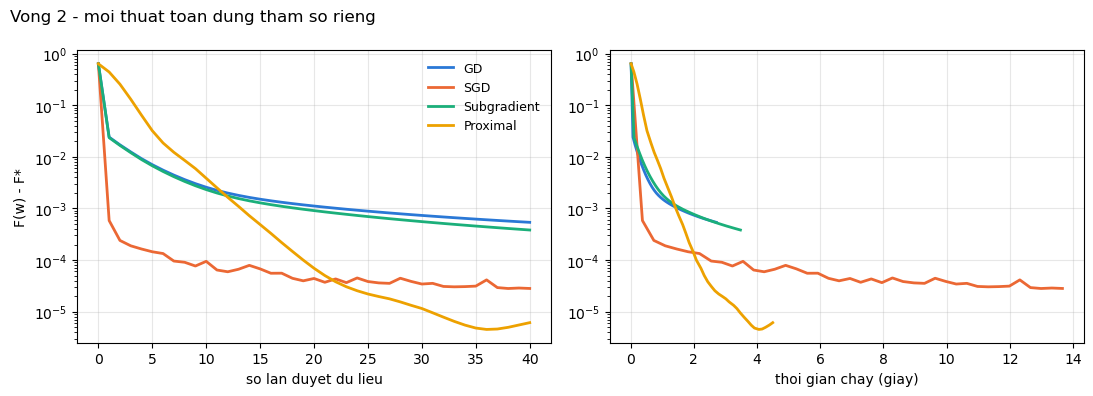

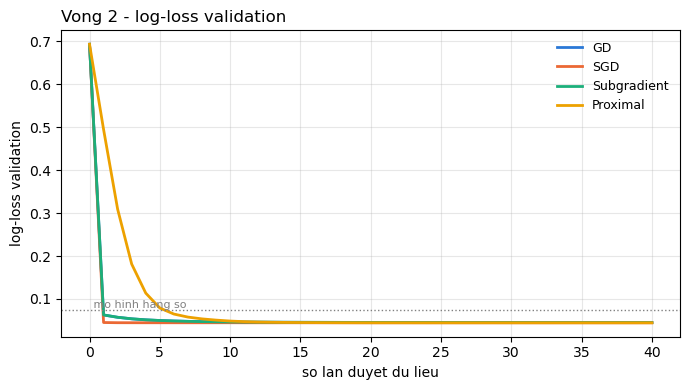

In [26]:
tot = [tot_gd, tot_sgd, tot_sub, tot_prox]
ev2 = [t[1] for t in tot]
in_bang([(TEN_4[i], tot[i][0], ev2[i]) for i in range(4)],
        "KET QUA VONG 2 (cau hinh tot nhat cua moi thuat toan)")

ve2 = [(TEN_4[i], tot[i][3]) for i in range(4)]
ve_hoi_tu(ve2, [F_sao(0.0), F_sao(0.0),
                F_sao(tot_sub[4]["lam1"]), F_sao(tot_prox[4]["lam1"])],
          "Vong 2 - moi thuat toan dung tham so rieng")
ve_val(ve2, "Vong 2 - log-loss validation")

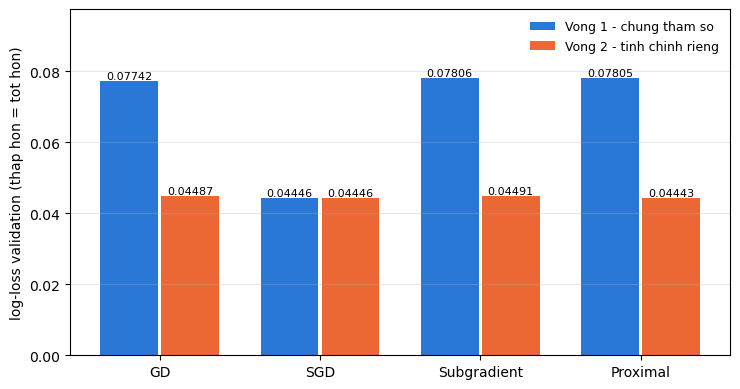

In [27]:
# So sanh 2 vong
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(4)
v1 = [e["val"] for e in ev1]
v2 = [e["val"] for e in ev2]
ax.bar(x - 0.19, v1, 0.36, color=MAU[0], label="Vong 1 - chung tham so")
ax.bar(x + 0.19, v2, 0.36, color=MAU[1], label="Vong 2 - tinh chinh rieng")
for i in range(4):
    ax.text(x[i] - 0.19, v1[i], "%.5f" % v1[i], ha="center", va="bottom", fontsize=8)
    ax.text(x[i] + 0.19, v2[i], "%.5f" % v2[i], ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(TEN_4)
ax.set_ylabel("log-loss validation (thap hon = tot hon)")
ax.set_ylim(0, max(v1 + v2) * 1.25); ax.grid(alpha=0.3, axis="y")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

## 9. Nhận xét

In [28]:
print("%-13s%12s%12s%11s   %s" %
      ("thuat toan", "val vong 1", "val vong 2", "cai thien", "cau hinh thang"))
print("-" * 88)
for i in range(4):
    ct = (ev1[i]["val"] - ev2[i]["val"]) / ev1[i]["val"] * 100
    print("%-13s%12.6f%12.6f%10.2f%%   %s" %
          (TEN_4[i], ev1[i]["val"], ev2[i]["val"], ct, tot[i][0]))

print("\nDo thua o VONG 1 (luc do ca 4 dung chung lam1 = %g):" % lam1)
for i in range(4):
    print("   %-13s nnz = %2d/%d" % (TEN_4[i], ev1[i]["nnz"], d))

# Kiem tra dieu kien toi uu KKT: 0 thuoc dF(w*) ?
print("\n||duoi dao ham chuan nho nhat||:")
print("   tai nghiem tham chieu = %.3e  (~0 => dung la nghiem toi uu)" %
      np.linalg.norm(duoi_dao_ham(bo_nho[lam1][1], X_tr, y_tr, lam1, lam2)))
print("   tai w = 0             = %.3e" %
      np.linalg.norm(duoi_dao_ham(np.zeros(d), X_tr, y_tr, lam1, lam2)))

# Do thua that su den dau? Thu doi cach chon phan tu trong dF
w_r, _ = SUBGRADIENT(X_tr, y_tr, val, lam1, lam2, eta0=eta, so_vong=VONG,
                     kieu_buoc="1/sqrt(k)", cach_chon="random")
w_m, _ = SUBGRADIENT(X_tr, y_tr, val, lam1, lam2, eta0=eta, so_vong=VONG,
                     kieu_buoc="1/sqrt(k)", cach_chon="min_norm")
print("\nSubgradient voi cach_chon='min_norm': nnz = %d/%d" % (np.sum(w_m != 0), d))
print("Subgradient voi cach_chon='random'  : nnz = %d/%d" % (np.sum(w_r != 0), d))

thuat toan     val vong 1  val vong 2  cai thien   cau hinh thang
----------------------------------------------------------------------------------------
GD               0.077420    0.044865     42.05%   buoc 20/L
SGD              0.044459    0.044456      0.01%   B=1024, eta0=2, buoc 1/k
Subgradient      0.078062    0.044911     42.47%   eta0=20/L, hang_so, lam1=0.0001
Proximal         0.078055    0.044434     43.07%   FISTA, line search, lam1=0.0001

Do thua o VONG 1 (luc do ca 4 dung chung lam1 = 0.001):
   GD            nnz = 38/38
   SGD           nnz = 38/38
   Subgradient   nnz = 30/38
   Proximal      nnz = 25/38

||duoi dao ham chuan nho nhat||:
   tai nghiem tham chieu = 1.407e-05  (~0 => dung la nghiem toi uu)
   tai w = 0             = 4.861e-01



Subgradient voi cach_chon='min_norm': nnz = 30/38
Subgradient voi cach_chon='random'  : nnz = 38/38


**(a) "Cùng một bộ tham số" không có nghĩa là công bằng.** Bước $1/L$ suy ra từ chặn
Lipschitz nhưng đó là bước của GD; SGD thấy nó quá nhỏ, subgradient thì cần bước giảm
dần chứ không phải bước hằng. Sau khi mỗi thuật toán được dò tham số riêng (vòng 2),
khoảng cách giữa **cấu hình tốt nhất và tệ nhất trong cùng một thuật toán** còn lớn hơn
khoảng cách **giữa các thuật toán** → chọn tham số quan trọng hơn chọn thuật toán.

**(b) Về độ thưa** — khác biệt bản chất giữa hai cách xử lý L1:

| | cơ chế tạo số 0 |
|---|---|
| GD, SGD | không có |
| Subgradient | chỉ là *phụ phẩm* của quy ước chọn phần tử: khi $|\nabla_j f|\le\lambda_1$ thì phần tử chuẩn nhỏ nhất **bằng đúng 0** nên $w_j$ "dính" lại 0. Đổi sang `cach_chon="random"` là **đặc hoàn toàn** (xem ô trên). |
| Proximal | **theo cấu trúc**: soft-thresholding đặt hẳn hệ số về 0 ở *mọi* vòng lặp |

**(c) Tốc độ lý thuyết** — lý do proximal thắng khi có L1:

| | Bài toán | Tốc độ | Số vòng để đạt sai số $\varepsilon$ |
|---|---|---|---|
| GD | trơn | $O(1/k)$ | $O(1/\varepsilon)$ |
| SGD | trơn | $O(1/\sqrt k)$ | mỗi bước rẻ hơn $n/B$ lần |
| Subgradient | + L1 | $O(1/\sqrt k)$ | $O(1/\varepsilon^2)$ |
| ISTA | + L1 | $O(1/k)$ | $O(1/\varepsilon)$ |
| FISTA | + L1 | $O(1/k^2)$ | $O(1/\sqrt\varepsilon)$ |

**(d) Số lần duyệt dữ liệu ≠ thời gian thực.** SGD tiến nhanh nhất tính theo số lần duyệt,
nhưng mỗi epoch nó gọi ~614 phép nhân ma trận nhỏ, còn GD/ISTA chỉ gọi **một** phép nhân
lớn — numpy/BLAS chạy phép lớn hiệu quả hơn nhiều khi $d$ nhỏ. Ưu thế $O(Bd)$ của SGD chỉ
thành ưu thế thực tế khi $d$ lớn hoặc dữ liệu không vừa bộ nhớ.

**Kết luận:** khi hàm mục tiêu tách được thành *trơn + không trơn*, đừng dùng subgradient —
hãy khai thác cấu trúc: gradient cho phần trơn, **prox** cho phần không trơn. Và luôn so
sánh trên cùng một ngân sách, nhìn cả hai trục: số lần duyệt dữ liệu *và* thời gian thực.